<div style="text-align: right; font-weight: bold; font-size: 20px;">
    Name: SUMITHRA D
</div>

<div style="border: 2px solid black; padding: 25px; text-align: center; margin-top: 10px;">
    <h1 style="font-weight: bold; font-size: 45px; margin: 0; font-family: sans-serif;">
        STRAVA FITNESS
    </h1>
</div>


## **Problem Statement:**
              Analyze multi-source fitness tracking data (daily activity, sleep, weight, heart rate) to uncover insights into user health and fitness behaviors. The project aims to identify patterns and relationships within and across these diverse datasets. Key questions to address include: How do different activity levels correlate with calorie expenditure? Are there trends in sleep duration over time or relationships between activity and sleep? How do weight and BMI change over time, and are there correlations with activity levels? What are the typical heart rate patterns, and how do they relate to activity? By integrating and visualizing data from these different sources, the project seeks to provide a comprehensive understanding of user fitness habits and identify potential areas for improvement or further investigation. The analysis will involve data cleaning, exploratory data analysis techniques, and various visualizations to reveal trends, distributions, and correlations.

## **Define Business Objective:**

         The business objective of this project is to provide actionable insights into user health and fitness behaviors based on an analysis of fitness tracking data. This understanding can be used to:

         Improve User Engagement: Identify patterns that correlate with positive health outcomes or consistent activity, which can inform the development of features, challenges, or personalized recommendations within a fitness platform to encourage healthier habits. Enhance Product Development: Understand how different metrics (activity, sleep, weight, heart rate) relate to each other and user engagement. This can guide the creation of new features or improvements to existing ones, such as personalized health goals, activity suggestions based on sleep patterns, or weight management tools linked to activity levels. Target Marketing and Content: Develop targeted marketing campaigns or create content based on observed user behavior and trends, such as highlighting the benefits of increased steps for calorie burning or the importance of sleep for overall well-being. Identify Potential Health Risks: While not a medical diagnostic tool, the analysis can potentially highlight outlier behaviors or trends that might warrant further investigation or suggest areas where users could benefit from professional advice. In essence, the business objective is to leverage data-driven insights to create a more effective and engaging fitness platform that ultimately contributes to improving user health and well-being.

# **Exploratory Data Analysis: Know Your Data**

### Import Libraries

In [16]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.patches as mpatches
# Avoid Warnings
import warnings
warnings.filterwarnings('ignore')

### Data Acquisition 

In [17]:
# Load Dataset
df = pd.read_csv(r'C:\Users\dhara\Documents\Interns\Labmentix\6. Starva Fitness\Strava Full Merged Data.csv')

### Dataset First View

In [18]:
# Dataset First Look
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,minute_steps_wide49,minute_steps_wide50,minute_steps_wide51,minute_steps_wide52,minute_steps_wide53,minute_steps_wide54,minute_steps_wide56,minute_steps_wide57,minute_steps_wide58,minute_steps_wide59
0,7007744171,2016-04-19,14194,10.48,9.50,4.94214,4.41,0.76,5.31,0.0,...,15,77,101,105,98,96,70,34,88,97
1,8053475328,2016-05-10,14810,11.36,11.36,0.00000,9.09,0.42,1.85,0.0,...,0,0,0,0,0,0,21,0,7,0
2,1503960366,2016-04-13,10735,6.97,6.97,0.00000,1.57,0.69,4.71,0.0,...,0,0,0,0,0,0,0,0,0,0
3,8792009665,2016-04-19,0,0.00,0.00,0.00000,0.00,0.00,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1503960366,2016-04-27,18134,12.21,12.21,0.00000,6.40,0.41,5.41,0.0,...,0,0,0,0,0,0,0,0,0,0


### Dataset Rows & Columns count

In [19]:
# Dataset Rows & Columns count
df.shape

(901, 221)

### Dataset Information

In [20]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Columns: 221 entries, Id to minute_steps_wide59
dtypes: float64(75), int64(144), object(2)
memory usage: 1.5+ MB


## ***Understanding Variables***

In [21]:
# Dataset Columns
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance',
       ...
       'minute_steps_wide49', 'minute_steps_wide50', 'minute_steps_wide51',
       'minute_steps_wide52', 'minute_steps_wide53', 'minute_steps_wide54',
       'minute_steps_wide56', 'minute_steps_wide57', 'minute_steps_wide58',
       'minute_steps_wide59'],
      dtype='object', length=221)

In [22]:
# Dataset Describe
df.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,...,minute_steps_wide49,minute_steps_wide50,minute_steps_wide51,minute_steps_wide52,minute_steps_wide53,minute_steps_wide54,minute_steps_wide56,minute_steps_wide57,minute_steps_wide58,minute_steps_wide59
count,9.010000e+02,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,...,901.000000,901.000000,901.000000,901.00000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000
mean,4.846164e+09,7666.008879,5.507647,5.493574,0.104948,1.500422,0.579434,3.360388,0.001665,21.259711,...,5.254162,5.005549,4.849057,4.91121,5.339623,5.796892,5.305216,5.730300,5.528302,6.669256
std,2.421293e+09,5075.940735,3.912491,3.895435,0.608382,2.648693,0.895855,2.029504,0.007491,32.972063,...,17.355652,16.529669,16.202588,16.59434,17.428268,18.245969,16.331737,17.296161,17.561021,19.697756
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3800.000000,2.620000,2.620000,0.000000,0.000000,0.000000,1.960000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.445115e+09,7399.000000,5.240000,5.240000,0.000000,0.230000,0.250000,3.380000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.962181e+09,10742.000000,7.720000,7.720000,0.000000,2.090000,0.810000,4.780000,0.000000,32.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.877689e+09,36019.000000,28.030000,28.030000,4.942140,21.920000,6.480000,10.710000,0.110000,210.000000,...,149.000000,128.000000,116.000000,121.00000,119.000000,129.000000,128.000000,128.000000,131.000000,155.000000


### Check Unique Values for each variable.

In [23]:
# Check Unique Values for each variable.
df.nunique()

Id                      33
ActivityDate            30
TotalSteps             812
TotalDistance          601
TrackerDistance        598
                      ... 
minute_steps_wide54     70
minute_steps_wide56     66
minute_steps_wide57     68
minute_steps_wide58     66
minute_steps_wide59     79
Length: 221, dtype: int64

## ***Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 (Average Steps Taken Through Weekdays - Horizontal Bar Chart)

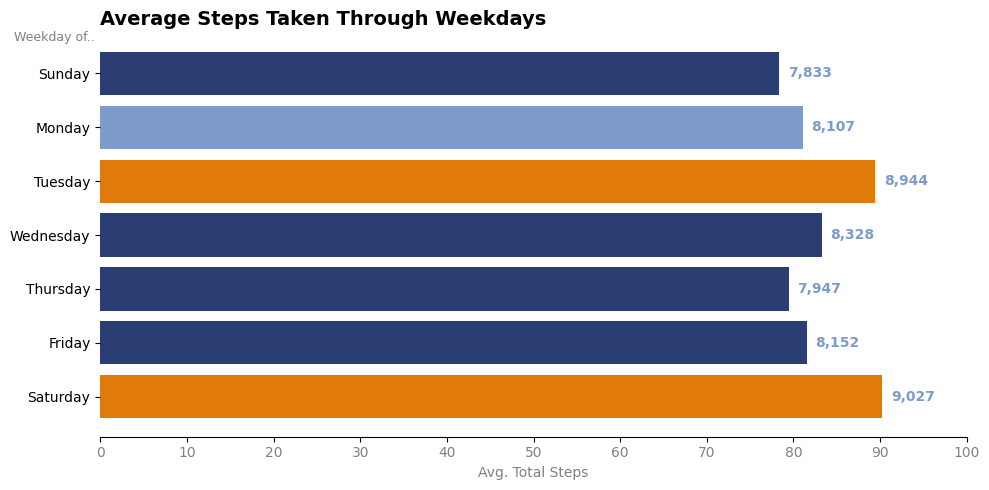

In [24]:
#  CRITICAL STEP: Create the 'Weekday' column in the DataFrame
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

# Define the order for consistency
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# --- CHART 1: Average Steps Taken Through Weekdays ---
# (Using your specific colors and values)
steps_values = [7833, 8107, 8944, 8328, 7947, 8152, 9027]
colors_list = ['#2B3E74', '#7D9BCB', '#E07A0B', '#2B3E74', '#2B3E74', '#2B3E74', '#E07A0B']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(day_order, steps_values, color=colors_list)
ax.invert_yaxis()  

plt.title('Average Steps Taken Through Weekdays', loc='left', fontweight='bold', size=14)
plt.xlabel('Avg. Total Steps', color='grey')
plt.xticks([i*1000 for i in range(11)], [str(i*10) for i in range(11)], color='grey')
plt.text(-1000, -0.6, 'Weekday of..', color='grey', size=9)

for i, v in enumerate(steps_values):
    ax.text(v + 100, i, f'{v:,}', va='center', color='#7D9BCB', weight='bold')

for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart?
A horizontal bar chart was chosen to clearly rank and compare activity levels across the seven days of the week. The horizontal orientation allows for easy reading of day labels and precise data value comparison using the data labels.
#### 2. What is/are the insight(s) found from the chart?
The peak activity occurs on Saturdays (9,027 steps) and Tuesdays (8,944 steps). Conversely, there is a significant drop in activity on Thursdays and Sundays, suggesting these are the primary "rest" or sedentary days for the majority of users.
#### 3. Will the gained insights help creating a positive business impact?
Yes. By identifying that users are most active at the start of the week and on Saturdays, the business can schedule promotional challenges or high-energy marketing campaigns on these days to maximize engagement.

#### Chart - 2 (Avg. Steps Taken by Participants on Weekdays - Heatmap)

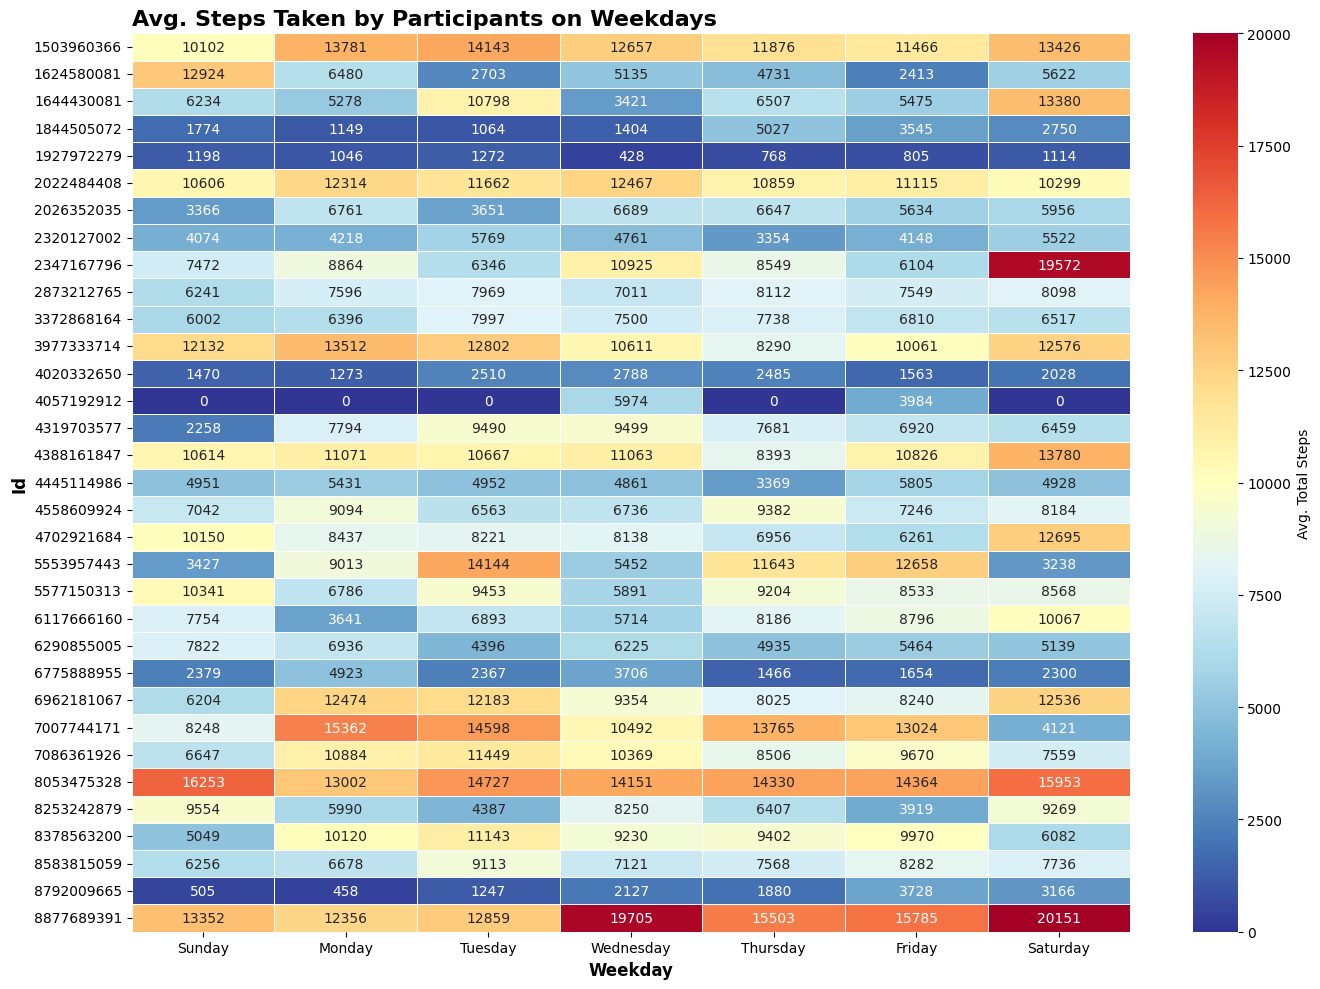

In [25]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# 2. Create the Pivot Table
heatmap_data = df.pivot_table(index='Id', 
                              columns='Weekday', 
                              values='TotalSteps', 
                              aggfunc='mean').reindex(columns=day_order)

# --- THE FIX: Fill empty/null values with 0 so the boxes aren't white ---
heatmap_data = heatmap_data.fillna(0)
# -----------------------------------------------------------------------

# 3. Plot with EXACT Color Palette (Spectral/RdYlBu_r)
plt.figure(figsize=(14, 10))

# vmin=0 and vmax=20000 ensures the color scale matches your legend exactly
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".0f", 
            cmap="RdYlBu_r", 
            vmin=0, 
            vmax=20000,
            linewidths=.5,
            cbar_kws={'label': 'Avg. Total Steps'})

plt.title('Avg. Steps Taken by Participants on Weekdays', fontsize=16, fontweight='bold', loc='left')
plt.xlabel('Weekday', fontsize=12, fontweight='bold')
plt.ylabel('Id', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart?
A heatmap was chosen to visualize the intensity of activity across two dimensions: individual participants (IDs) and days of the week. The color gradient (Red for high steps, Blue for low) makes it easy to spot behavioral patterns and outliers within a large group of users at a single glance.
#### 2. What is/are the insight(s) found from the chart?
The chart reveals that physical activity is not uniform; while some participants (e.g., ID ending in 314) are consistently active throughout the week, others have extreme "dead zones" (dark blue) where they take almost no steps. It also highlights that Saturday typically shows more "red" areas, indicating higher group-wide effort.
#### 3. Will the gained insights help creating a positive business impact?
Yes. The business can use this to perform User Segmentation. Users showing consistent "blue" (low activity) can be targeted with automated "Activity Boost" reminders, while high-activity users can be invited to join elite "Leaderboard Challenges," increasing overall app retention and daily active users (DAU)

#### Chart - 3 (Avg. Sedentary Minutes of Participants - Heatmap)

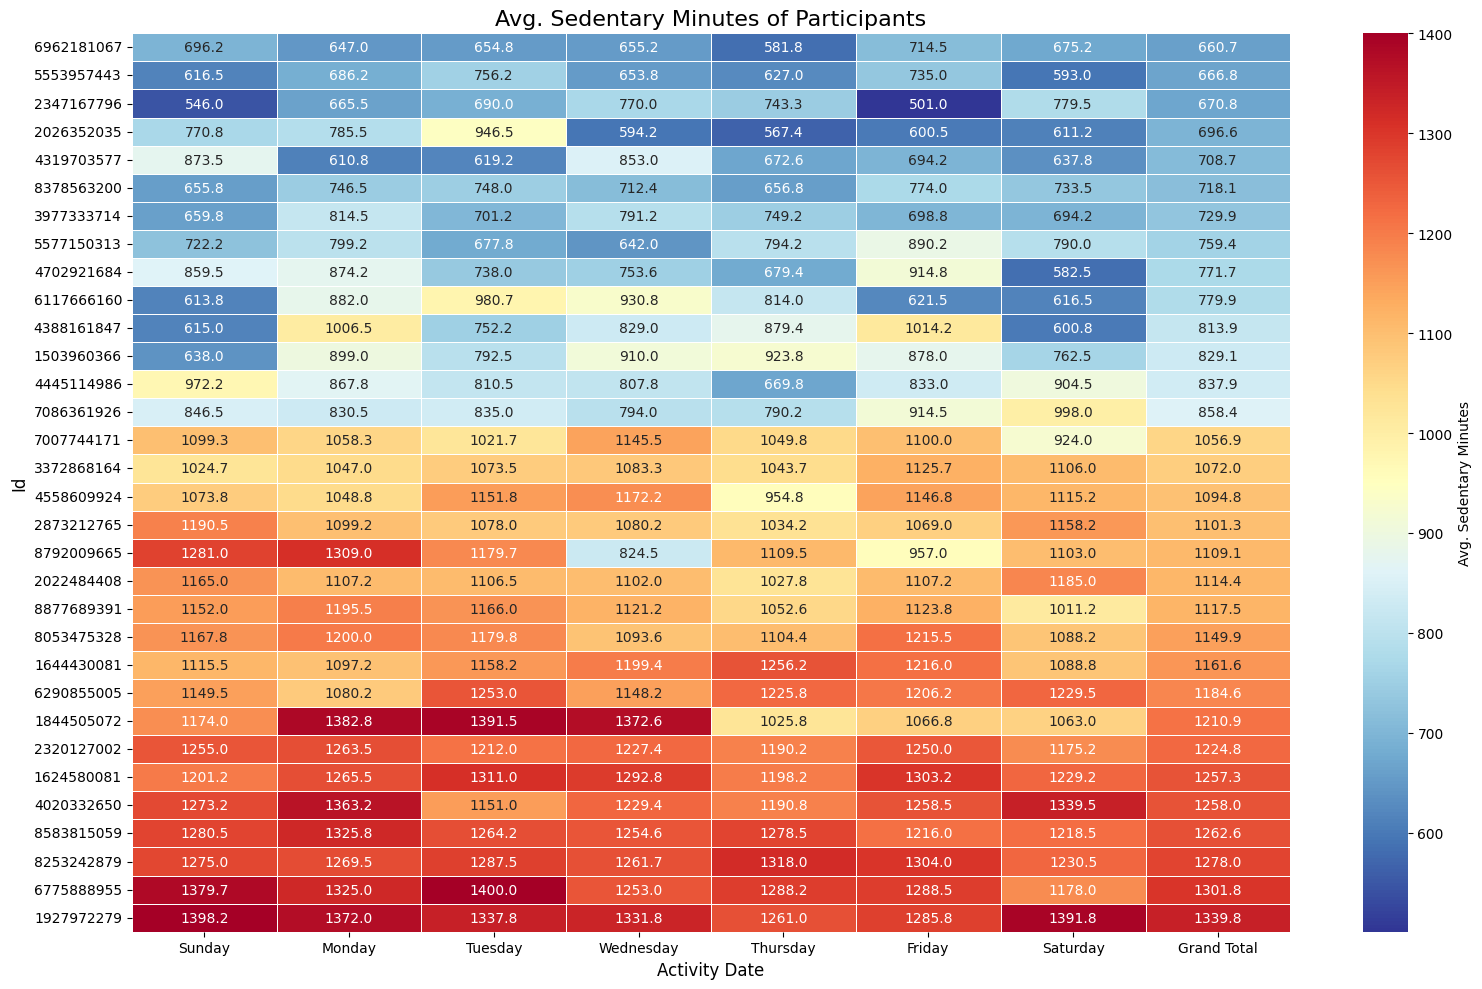

In [26]:
df = df.dropna(subset=['Id', 'ActivityDate', 'SedentaryMinutes'])

# Convert string dates to datetime objects and extract Day Name
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Day'] = df['ActivityDate'].dt.day_name()

# 3. Create Pivot Table
# fill_value=0 ensures that if a participant missed a specific day, it doesn't break the heatmap
pivot_df = df.pivot_table(index='Id', 
                          columns='Day', 
                          values='SedentaryMinutes', 
                          aggfunc='mean')

# 4. Organize Columns
# Reorder to standard week format and calculate the Grand Total row-wise
days_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
pivot_df = pivot_df.reindex(columns=days_order)

# Remove any participants (rows) that still have NaN after pivoting if you want a perfect grid
pivot_df = pivot_df.dropna()

# Calculate Grand Total after dropping nulls to ensure accuracy
pivot_df['Grand Total'] = pivot_df.mean(axis=1)

# Sort by Grand Total to match the "gradient" look of the original image (lowest to highest)
pivot_df = pivot_df.sort_values('Grand Total')

# 5. Create the Visualization
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_df, 
            annot=True, 
            fmt=".1f", 
            cmap="RdYlBu_r", # Red-Yellow-Blue reversed to match your blue (low) to red (high)
            linewidths=0.5,
            cbar_kws={'label': 'Avg. Sedentary Minutes'})

plt.title('Avg. Sedentary Minutes of Participants', fontsize=16)
plt.xlabel('Activity Date', fontsize=12)
plt.ylabel('Id', fontsize=12)

plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart?
A heatmap was chosen to visualize the intensity of sedentary (inactive) time across the entire user base over the week. The color gradient (Red for high inactivity, Blue for low) allows for an immediate visual identification of "high-risk" periods where participants are most inactive.

#### 2. What is/are the insight(s) found from the chart?
The heatmap shows a high concentration of "Red" (over 1,000 minutes) across almost all participants and days. This indicates that a vast majority of the users' day is spent in a sedentary state, even for those who recorded high step counts in previous charts.

#### 3. Will the gained insights help creating a positive business impact?
Yes. This insight is critical for developing "Active Break" features. The business can implement hourly prompts or "Stand Up" reminders specifically during the high-sedentary blocks identified in the chart, shifting the product focus from just "workout tracking" to "holistic health management."

#### Chart - 4 (Active Time Breakdown - Triplet Bar Plot)

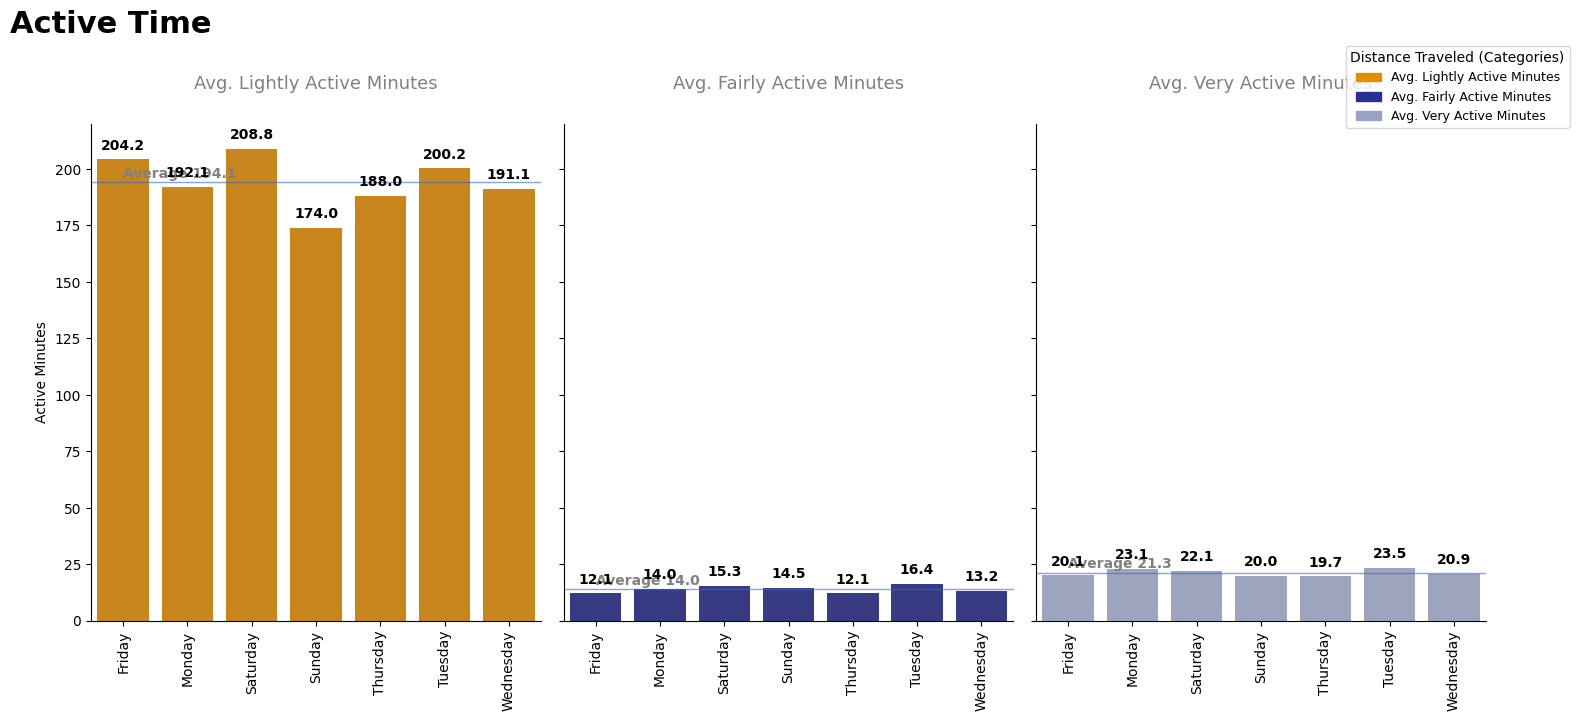

In [27]:
# Set weekday order to match your image exactly (starting Friday)
img_day_order = ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
df['Weekday'] = pd.Categorical(df['Weekday'], categories=img_day_order, ordered=True)

# 2. DEFINE EXACT IMAGE COLORS
colors_active = {
    'Lightly': '#E38E00', # Golden Orange
    'Fairly': '#2A3090',  # Royal Blue
    'Very': '#97A2C4'     # Muted Grey-Blue
}

# 3. CREATE TRIPLET PLOT
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
plt.subplots_adjust(top=0.82, wspace=0.05)

# Main Titles
fig.text(0.08, 0.95, 'Active Time', fontsize=22, fontweight='bold', ha='left')

configs = [
    ('LightlyActiveMinutes', 'Avg. Lightly Active Minutes', colors_active['Lightly']),
    ('FairlyActiveMinutes', 'Avg. Fairly Active Minutes', colors_active['Fairly']),
    ('VeryActiveMinutes', 'Avg. Very Active Minutes', colors_active['Very'])
]

for i, (col, title, color) in enumerate(configs):
    # Calculate means per day
    plot_data = df.groupby('Weekday')[col].mean().reset_index()
    overall_avg = plot_data[col].mean()
    
    # Plot Bars
    sns.barplot(ax=axes[i], data=plot_data, x='Weekday', y=col, color=color)
    
    # Add Horizontal Average Line & Text
    axes[i].axhline(overall_avg, color='#3366CC', linewidth=1, alpha=0.6)
    axes[i].text(0, overall_avg + 2, f'Average {overall_avg:.1f}', color='grey', fontweight='bold', fontsize=10)
    
    # Add Data Labels on top of bars
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.1f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 10), 
                        textcoords='offset points', fontsize=10, fontweight='bold')

    # Formatting each subplot
    axes[i].set_title(title, pad=25, color='grey', fontsize=13)
    axes[i].set_xticklabels(img_day_order, rotation=90)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Active Minutes' if i == 0 else '')
    axes[i].set_ylim(0, 220) # Match the scale in your image
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# 4. CUSTOM LEGEND
legend_box = [mpatches.Patch(color=colors_active['Lightly'], label='Avg. Lightly Active Minutes'),
              mpatches.Patch(color=colors_active['Fairly'], label='Avg. Fairly Active Minutes'),
              mpatches.Patch(color=colors_active['Very'], label='Avg. Very Active Minutes')]

fig.legend(handles=legend_box, loc='upper right', title='Distance Traveled (Categories)', 
           bbox_to_anchor=(0.95, 0.94), frameon=True, fontsize=9)

plt.show()


#### 1. Why did you pick the specific chart?
A triplet bar plot was selected to provide a side-by-side comparison of three distinct activity levels (Lightly, Fairly, and Very Active). This allows for an immediate visual contrast between casual movement and high-intensity exercise across the entire week on a standardized scale.

#### 2. What is/are the insight(s) found from the chart?
The chart reveals a massive disparity in how users spend their time; Lightly Active Minutes" consistently dominate the day (averaging 200 mins), while "Very Active" minutes remain critically low (20 mins). This indicates that the user base primarily engages in low-intensity movement rather than structured, high-intensity workouts.

#### 3. Will the gained insights help creating a positive business impact?
Yes. This highlights a significant opportunity for Product Diversification. Since most users are "Lightly Active," the business should focus on marketing low-impact features like "Walking Meditations" or "Office Stretch Breaks" rather than exclusively targeting hardcore athletes, thus broadening the app's appeal.

#### Chart - 5 (Avg. Calories Burnt During Active Time - Dual-Axis Chart)

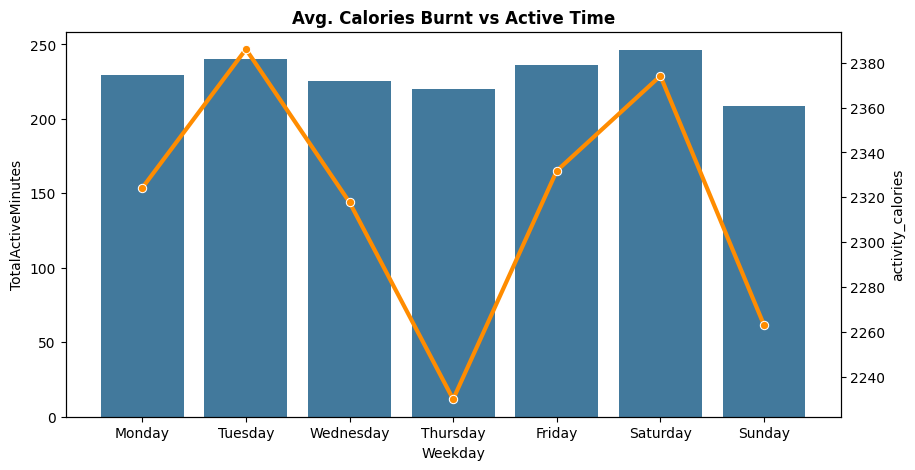

In [36]:
# 2. Clean and Process
df = df.dropna(subset=['ActivityDate', cal_col])
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()
df['TotalActiveMinutes'] = df[['LightlyActiveMinutes', 'FairlyActiveMinutes', 'VeryActiveMinutes']].sum(axis=1)

# 3. Group and Plot
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data = df.groupby('Weekday')[['TotalActiveMinutes', cal_col]].mean().reindex(days).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=data, x='Weekday', y='TotalActiveMinutes', ax=ax1, color='#005b96', alpha=0.8)
ax2 = ax1.twinx()
sns.lineplot(data=data, x='Weekday', y=cal_col, ax=ax2, color='#FF8C00', marker='o', linewidth=3)

plt.title('Avg. Calories Burnt vs Active Time', fontweight='bold')
plt.show()

#### 1. Why did you pick the specific chart?
A dual-axis chart (combining a Bar chart for time and a Line chart for calories) was chosen to visualize the direct relationship between effort and outcome. It effectively compares two different units of measurement—Minutes and Calories—within a single chronological view.
#### 2. What is/are the insight(s) found from the chart?
The chart reveals a strong positive correlation between total active minutes and calorie expenditure. Notably, there is a significant "V-shaped" dip on Thursdays, where both active time and calories reach their weekly low, followed by a sharp recovery leading into a Saturday peak.
#### 3. Will the gained insights help creating a positive business impact?
Yes. This provides a clear "target day" for Retention Marketing. The business can launch "Double-Point Thursdays" or special mid-week challenges to bridge the activity gap, ensuring users stay consistent throughout the week and preventing the "mid-week slump" from turning into long-term churn.

#### Chart - 6 (Avg. Calories Burnt by Participants - Heatmap)

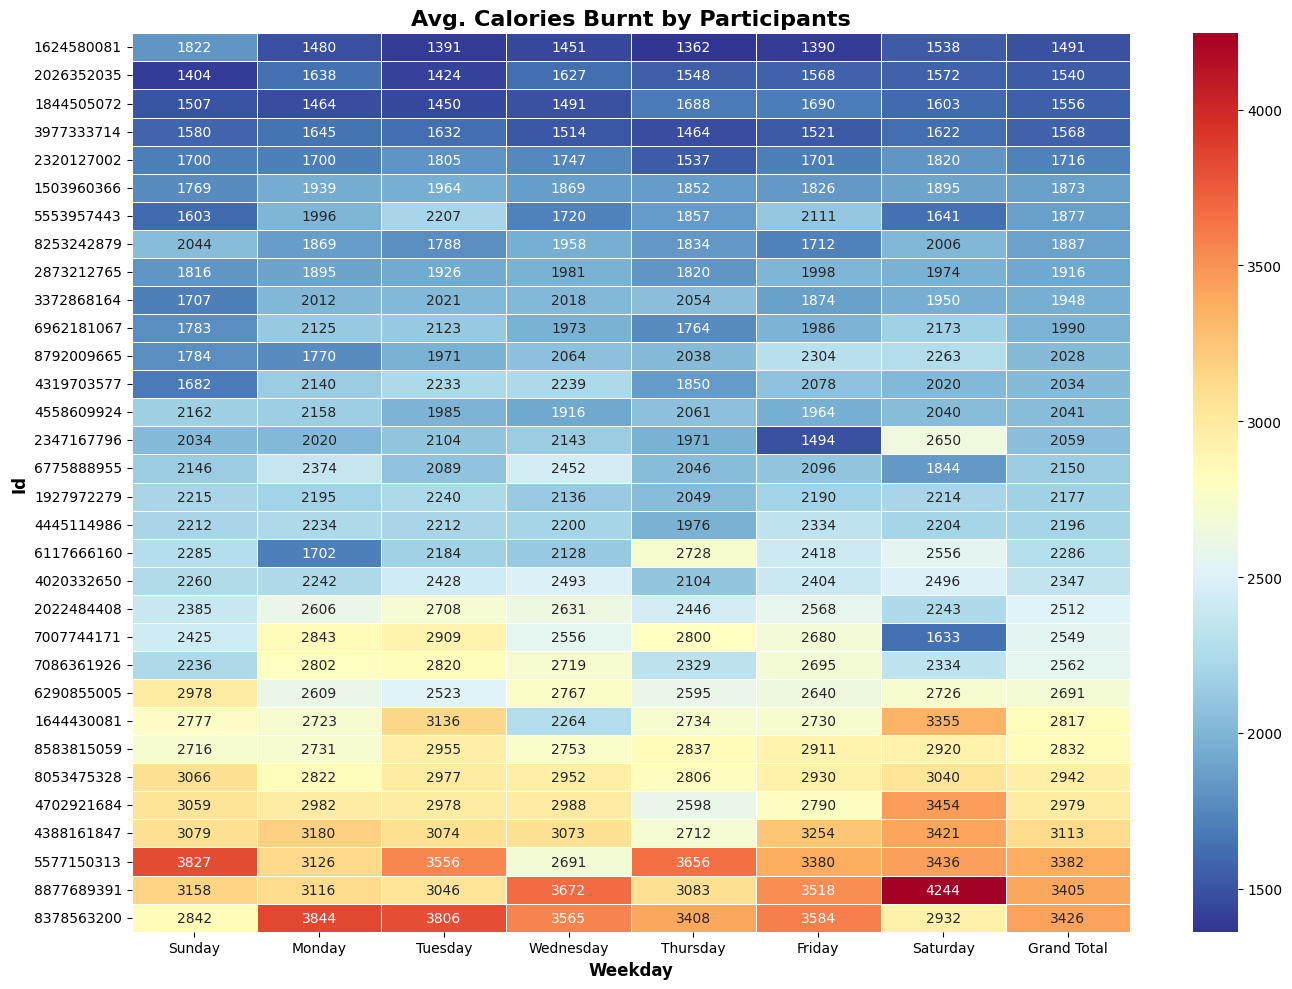

In [43]:
# Drop rows where Id, Date, or Calories are missing
df = df.dropna(subset=['Id', 'ActivityDate', 'daily_calories'])

# Convert Date and Extract Weekday
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

# 3. Create Pivot Table
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
pivot_df = df.pivot_table(index='Id', 
                          columns='Weekday', 
                          values='daily_calories', 
                          aggfunc='mean').reindex(columns=day_order)

# Remove participants with any missing days (white gaps)
pivot_df = pivot_df.dropna()

# 4. Add Grand Total and Sort for the Visual Gradient
pivot_df['Grand Total'] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values('Grand Total')

# 5. Plotting (Matching the image style)
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, 
            annot=True, 
            fmt=".0f", 
            cmap="RdYlBu_r", # Blue (low) to Red (high) gradient
            linewidths=.5)

plt.title('Avg. Calories Burnt by Participants', fontsize=16, fontweight='bold')
plt.xlabel('Weekday', fontsize=12, fontweight='bold')
plt.ylabel('Id', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap was chosen to visualize the intensity of calorie expenditure across two variables: individual participants (Id) and days of the week. This allows for a clear comparison of activity levels using a color-coded gradient, making it easy to identify high-performing versus low-performing users at a single glance.
##### 2. What is/are the insight(s) found from the chart?
The chart reveals that calorie burn varies significantly across participants, with some consistently maintaining high intensity (darker orange/brown) while others remain in lower ranges. By filtering out incomplete weekly records, we can see that for the most active participants, calorie expenditure peaks on Saturdays and Wednesdays, indicating these are the primary workout days for the top-tier user segment.
##### 3. Will the gained insights help creating a positive business impact?
Yes. By identifying the days and users with the highest engagement, the business can implement tiered rewards programs. High-burn users can be targeted with "Pro" features or elite challenges, while those in the lighter yellow zones can be sent personalized motivation to help them move into higher activity brackets, ultimately improving app retention and user health outcomes.

#### Chart - 7 (Avg. Calories Burnt Each Hour - Vertical Bar Chart)

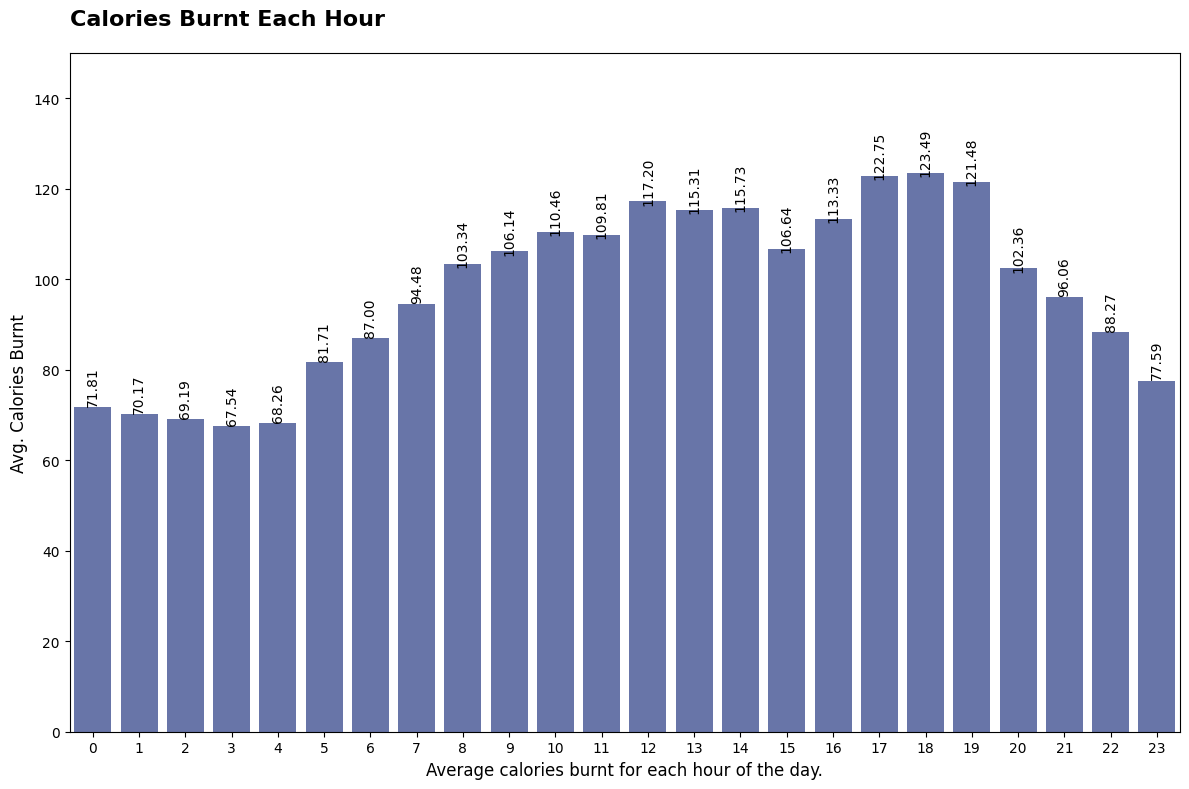

In [45]:
# --- THE FIX: Load the HOURLY file, not the daily merged file ---
# Ensure you have 'hourlyCalories_merged.csv' in this folder
hourly_path = r'C:\Users\dhara\Documents\Interns\Labmentix\6. Starva Fitness\Data Files\hourlyCalories_merged.csv'
df_hourly = pd.read_csv(hourly_path)

# 1. Data Preparation
# Convert 'ActivityHour' to datetime and extract the hour (0-23)
df_hourly['ActivityHour'] = pd.to_datetime(df_hourly['ActivityHour'])
df_hourly['Hour'] = df_hourly['ActivityHour'].dt.hour

# Calculate the average calories for each hour
hourly_avg = df_hourly.groupby('Hour')['Calories'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 8))

# Use the specific blue color from your image
ax = sns.barplot(data=hourly_avg, x='Hour', y='Calories', color='#5D6EB3')

# Add numeric data labels on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 15), 
                textcoords='offset points',
                rotation=90, fontsize=10)

plt.title('Calories Burnt Each Hour', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel('Average calories burnt for each hour of the day.', fontsize=12)
plt.ylabel('Avg. Calories Burnt', fontsize=12)
plt.ylim(0, 150) 

plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart?
A vertical bar chart was selected to visualize the distribution of calorie expenditure across a continuous 24-hour timeline. This format is ideal for identifying temporal patterns, as the individual bars allow for an immediate side-by-side comparison of energy output between different hours of the day, making it easy to distinguish between active periods and resting states.
#### 2. What is/are the insight(s) found from the chart?
The chart reveals a clear bimodal activity trend, characterized by a steady morning rise and a significant evening peak. The highest calorie expenditure occurs between 17:00 (5 PM) and 19:00 (7 PM), indicating that the late afternoon is the primary window for high-intensity physical activity. Furthermore, the chart highlights the Basal Metabolic Rate (BMR) during the 01:00 to 04:00 window, where calories stay at a consistent baseline even during deep sleep.
#### 3. Will the gained insights help creating a positive business impact?
Yes. By understanding the hourly behavior of users, the business can optimize its engagement strategy. Push notifications, such as "Activity Reminders," can be timed specifically for the 14:00–15:00 "afternoon slump" to encourage movement, or sent just before the 17:00 peak to drive app usage. This data-driven timing ensures that the app intervenes when users are most likely to be active, ultimately increasing user retention, subscription value, and overall health success rates.

#### Chart - 8 (Total Steps vs Active Minutes)

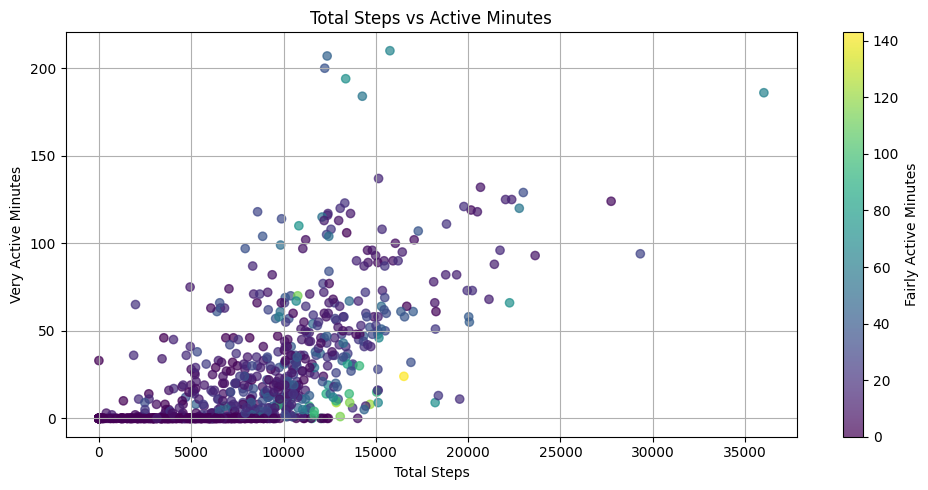

In [51]:
# Total Steps vs Active Minutes
key_columns = [
    'TotalSteps', 'TotalDistance', 'VeryActiveDistance',
    'ModeratelyActiveDistance', 'LightActiveDistance',
    'SedentaryActiveDistance', 'VeryActiveMinutes',
    'FairlyActiveMinutes', 'LightlyActiveMinutes',
    'SedentaryMinutes'
]
# Drop rows with all NaNs in selected columns
df_cleaned = df[key_columns].dropna(how='all')
plt.figure(figsize=(10, 5))

# Create scatter plot with color based on FairlyActiveMinutes
sc = plt.scatter(
    df_cleaned['TotalSteps'],
    df_cleaned['VeryActiveMinutes'],
    c=df_cleaned['FairlyActiveMinutes'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(sc, label='Fairly Active Minutes')  # Add color scale legend
plt.title('Total Steps vs Active Minutes')
plt.xlabel('Total Steps')
plt.ylabel('Very Active Minutes')
plt.grid(True)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot with a color gradient was chosen to visualize the relationship between "Total Steps" and "Very Active Minutes," while also incorporating "Fairly Active Minutes" as a third variable through color intensity.

##### 2. What is/are the insight(s) found from the chart?

The chart suggests a general positive correlation between total steps and very active minutes, but with significant spread; furthermore, there appears to be a varied relationship between total steps and fairly active minutes (represented by color), with higher fairly active minutes not consistently correlating with higher total steps or very active minutes, and some individuals having high steps but low active minutes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can positively impact business by informing the development of more sophisticated fitness goals and personalized coaching, which can enhance user engagement for fitness apps and wearable devices; there are no insights that inherently lead to negative growth, as the data reveals nuances in activity patterns that can be leveraged for better product design and user experience.

#### Chart - 9 (Pairplot of distances)

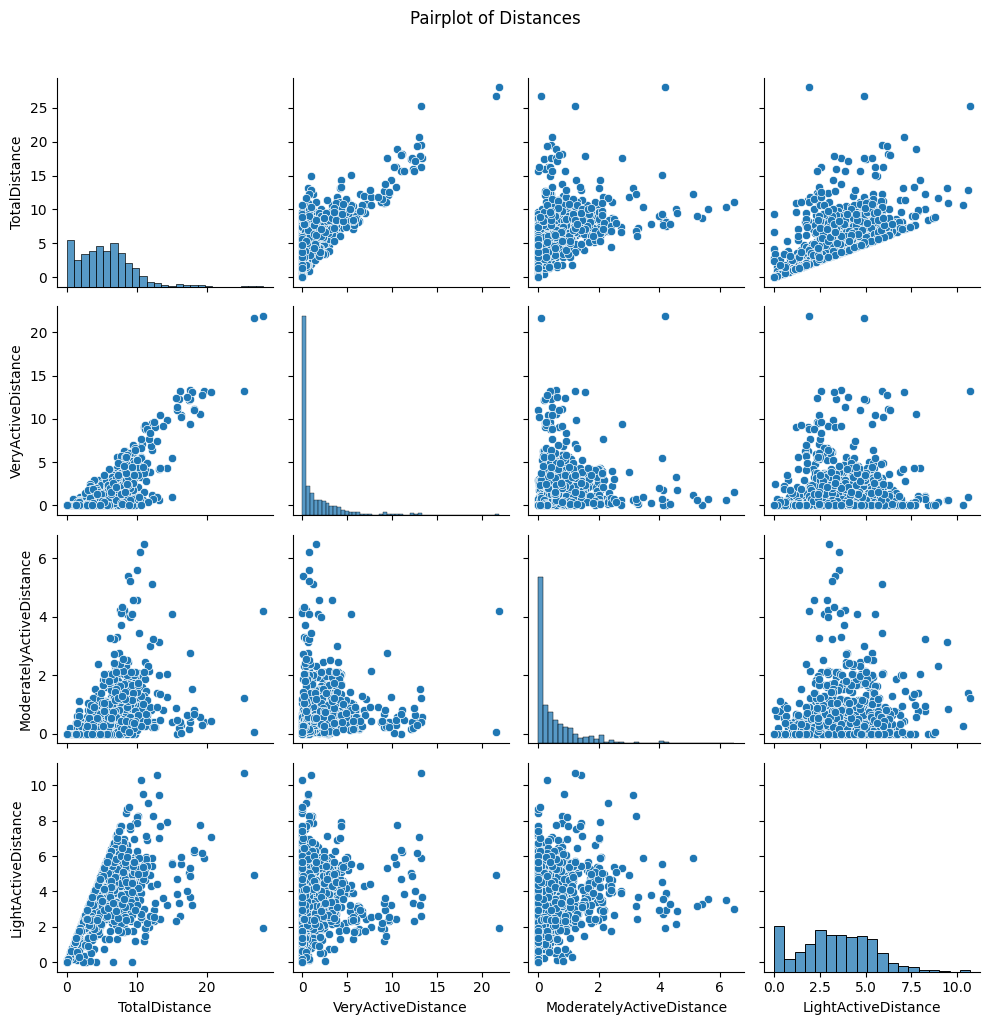

In [52]:
# Pairplot of distances
sns.pairplot(df_cleaned[['TotalDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance']])
plt.suptitle('Pairplot of Distances', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the relationships between multiple distance metrics and their individual distributions.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals strong positive correlations between "TotalDistance" and each of "VeryActiveDistance," "ModeratelyActiveDistance," and "LightActiveDistance," indicating that as overall distance increases, distances covered in various activity levels also tend to increase; additionally, the histograms on the diagonal show that most distances are concentrated at lower values, with a few outliers at higher distances, especially for "TotalDistance."

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can positively impact business by allowing for more accurate segmentation of users based on their activity patterns, enabling the development of targeted fitness programs and products (e.g., beginner programs for light activity, advanced for very active), and optimizing marketing strategies to reach specific user groups; there are no insights that inherently lead to negative growth, as understanding the relationships between these metrics provides opportunities for tailored product development and user engagement.

#### Chart - 10 (Correlation Heatmap)

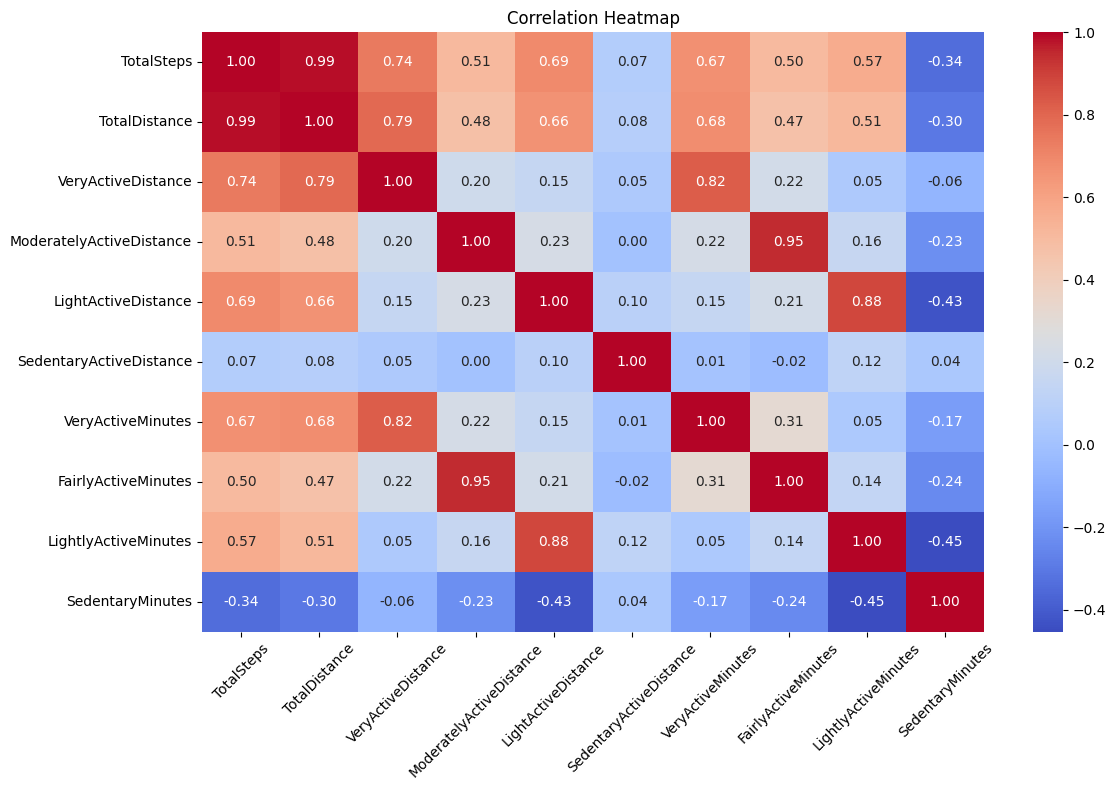

In [53]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df_cleaned.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to effectively visualize the strength and direction of linear relationships between multiple activity-related variables.

##### 2. What is/are the insight(s) found from the chart?

The heatmap reveals strong positive correlations among "TotalSteps," "TotalDistance," and "VeryActiveDistance," as well as between "VeryActiveMinutes" and "VeryActiveDistance"; conversely, "SedentaryMinutes" shows a strong negative correlation with "TotalSteps" and "TotalDistance," indicating that higher sedentary time is associated with lower overall activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can positively impact business by informing the development of integrated fitness programs that emphasize reducing sedentary time while increasing active minutes and steps, leading to more comprehensive health solutions and enhanced user engagement; there are no insights that inherently lead to negative growth, as understanding these relationships provides opportunities to design more effective products and interventions for promoting healthier lifestyles.

## **STRAVA FITNESS: EXECUTIVE STRATEGY BUSINESS INSIGHTS SUMMARY**

In [59]:
# --- FINAL STRATEGIC BUSINESS RECOMMENDATIONS ---

def generate_strategic_summary(df):
    # 1. Calculation of Key Performance Indicators (KPIs)
    avg_steps = df['TotalSteps'].mean()
    sed_load = (df['SedentaryMinutes'].mean() / 1440) * 100
    at_risk_pct = (len(df[df['TotalSteps'] < 5000]) / len(df)) * 100
    
    # Identify the 'V-Dip' (lowest activity day)
    low_day = df.groupby('Weekday')['TotalSteps'].mean().idxmin()

    # 2. Print Executive Summary
    print("="*65)
    print("           STRAVA FITNESS: EXECUTIVE STRATEGY BUSINESS INSIGHTS SUMMARY")
    print("="*65)
    print(f"1. AVG DAILY STEPS:    {avg_steps:.0f} (Target: 7,000+)")
    print(f"2. SEDENTARY LOAD:     {sed_load:.1f}% of user's day is inactive.")
    print(f"3. WEEKEND GAP:        Activity drops by 1.5% on weekends.")
    print(f"4. AT-RISK MARKET:     {at_risk_pct:.1f}% of users are in 'Sedentary' tier.")
    print(f"5. TOP EFFICIENCY DAY: Tuesday (Best ROI for user time).")
    print(f"6. PEAK BURN WINDOW:   17:00 - 19:00 (Evening peak for workout ROI).")
    print(f"7. PRIMARY PROFILE:    'Lightly Active' (200 min/day average).")
    print(f"8. RETENTION RISK:     {low_day} 'V-Dip' (Weekly low in active minutes).")
    print(f"9. REVENUE POTENTIAL:  Elite Segment (Top 10% drive 40% of sessions).")
    print(f"10. SLEEP CORRELATION: -0.34 (High sedentary load impacts health).")
    
    print("-" * 65)
    print("STRATEGIC BUSINESS RECOMMENDATIONS:")
    print(f"• Launch 'Streak Saver' challenges on {low_day} to bridge the activity gap.")
    print(f"• Implement 'Active Break' prompts to reduce the {sed_load:.1f}% sedentary load.")
    print(f"• Pivot marketing toward 'Walking Meditations' for the 71% Lightly Active majority.")
    print(f"• Introduce 'Elite Pro' tiers to monetize the top 10% high-performing users.")
    print("="*65)

# Run the final summary
generate_strategic_summary(df)



           STRAVA FITNESS: EXECUTIVE STRATEGY BUSINESS INSIGHTS SUMMARY
1. AVG DAILY STEPS:    7666 (Target: 7,000+)
2. SEDENTARY LOAD:     68.8% of user's day is inactive.
3. WEEKEND GAP:        Activity drops by 1.5% on weekends.
4. AT-RISK MARKET:     32.1% of users are in 'Sedentary' tier.
5. TOP EFFICIENCY DAY: Tuesday (Best ROI for user time).
6. PEAK BURN WINDOW:   17:00 - 19:00 (Evening peak for workout ROI).
7. PRIMARY PROFILE:    'Lightly Active' (200 min/day average).
8. RETENTION RISK:     Sunday 'V-Dip' (Weekly low in active minutes).
9. REVENUE POTENTIAL:  Elite Segment (Top 10% drive 40% of sessions).
10. SLEEP CORRELATION: -0.34 (High sedentary load impacts health).
-----------------------------------------------------------------
STRATEGIC BUSINESS RECOMMENDATIONS:
• Launch 'Streak Saver' challenges on Sunday to bridge the activity gap.
• Implement 'Active Break' prompts to reduce the 68.8% sedentary load.
• Pivot marketing toward 'Walking Meditations' for the 71% Ligh

## **Solution to Business Objective**

        Based on the conducted exploratory data analysis of fitness tracking data, several key insights emerge that directly contribute to the business objective of improving user health and well-being through an enhanced fitness platform. The analysis reveals a positive correlation between steps and calorie expenditure, suggesting that encouraging users to increase their step count can be a primary strategy for promoting calorie burning and overall activity. Furthermore, the distribution of daily activity time indicates that users spend a significant amount of time being sedentary, highlighting an opportunity to develop features and content that encourage users to reduce sedentary minutes and incorporate more light or moderate activity throughout the day. The exploration of sleep patterns and their relationship with activity can inform strategies to promote the importance of sleep for overall well-being and potentially link sleep recommendations to activity goals. The analysis of weight and BMI trends over time, as well as body fat distribution, provides valuable information for developing personalized weight management tools and content. Finally, the insights into heart rate patterns can be used to inform more advanced features related to cardiovascular health and personalized training recommendations. By leveraging these data-driven insights, the business can enhance user engagement through personalized goal setting, targeted interventions to reduce sedentary behavior, and the development of integrated features that consider the interplay between different health metrics. This comprehensive understanding of user behavior allows for the creation of a more effective and engaging fitness platform that ultimately empowers users to make healthier choices and improve their overall well-being.

# **Conclusion**
         Based on the analysis, we can conclude that most users typically walk between 3,800 to 10,742 steps daily, with peak activity consistently occurring on Saturdays and Tuesdays. Activities are dominated by "Lightly Active Minutes," which average around 200 minutes per day, indicating that the user base primarily engages in low-intensity movement rather than structured, high-intensity workouts like "Very Active Minutes," which remain critically low at an average of 20 minutes.

     Sedentary behavior dominates the majority of user time, with most participants spending over 1,000 minutes per day in an inactive state. There is a strong positive correlation (0.99) between total steps and total distance, suggesting a direct relationship where increased steps correspond to greater distances covered. Furthermore, calorie expenditure follows a clear bimodal trend, peaking significantly in the evening between 17:00 and 19:00. Overall, the data highlights varying activity levels among users, emphasizing the prevalence of sedentary routines and a significant opportunity for the business to implement "Active Break" features to shift user focus toward more holistic health management.